<a href="https://colab.research.google.com/github/yurisfurt/Mini-Projeto-SCTEC/blob/main/Atividade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns

# Qualquer coisa só pra criar o código lá dentro do Coolab

df = pd.read_csv('Base Varejo.csv', sep=';', encoding='latin-1')

print(df.head()) # Prévia
print(df.shape)

         DATA  CO_ID  CL_ID CL_GENERO  CL_EC  CL_FHL CL_SEG  PR_ID     PR_CAT  \
0  01/02/2019   1000    534         M      4       1      C     67    BEBIDAS   
1  01/02/2019   1000    534         M      4       1      C     70    BEBIDAS   
2  01/02/2019   1000    534         M      4       1      C    178    HIGIENE   
3  01/02/2019   1000    534         M      4       1      C      4  ALIMENTOS   
4  01/02/2019   1000    534         M      4       1      C    175    LIMPEZA   

                PR_NOME  Unnamed: 10  Unnamed: 11  Unnamed: 12  Unnamed: 13  
0  REFRIGERANTE GUARANA          NaN          NaN          NaN          NaN  
1   REFRIGERANTE OUTROS          NaN          NaN          NaN          NaN  
2       LENCO UMEDECIDO          NaN          NaN          NaN          NaN  
3               ABACAXI          NaN          NaN          NaN          NaN  
4     LIMPADOR MULTIUSO          NaN          NaN          NaN          NaN  
(830000, 14)


In [5]:
print(df.info()) # Mostra as colunas e os tipos de dados

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  object 
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3   CL_GENERO    830000 non-null  object 
 4   CL_EC        830000 non-null  int64  
 5   CL_FHL       830000 non-null  int64  
 6   CL_SEG       830000 non-null  object 
 7   PR_ID        830000 non-null  int64  
 8   PR_CAT       830000 non-null  object 
 9   PR_NOME      830000 non-null  object 
 10  Unnamed: 10  0 non-null       float64
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  0 non-null       float64
 13  Unnamed: 13  0 non-null       float64
dtypes: float64(4), int64(5), object(5)
memory usage: 88.7+ MB
None


In [6]:
print(df.isnull().sum())  # Conta valores nulos por coluna [2]
print(df.duplicated().sum())  # Conta linhas idênticas duplicadas [2]


DATA                0
CO_ID               0
CL_ID               0
CL_GENERO           0
CL_EC               0
CL_FHL              0
CL_SEG              0
PR_ID               0
PR_CAT              0
PR_NOME             0
Unnamed: 10    830000
Unnamed: 11    830000
Unnamed: 12    830000
Unnamed: 13    830000
dtype: int64
96553


In [7]:
# Remover linhas duplicadas
df = df.drop_duplicates()

In [10]:
# Remover Colunas Vazias e Linhas Duplicadas
cols_to_drop = ['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']
df = df.drop(columns=cols_to_drop)
df = df.drop_duplicates()
print({df.shape})
print({df.columns.tolist()})
df.head()

{(733447, 10)}


TypeError: unhashable type: 'list'

**Reasoning**:
I need to fix the print error from cell 3e207ebb and then perform the date conversion. I'll use a code block to handle both.



In [11]:
# Corrigir Exibição dos Dados e Conversão de Data

# Fix the previous printing error and show clean data info
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Convert DATA to datetime
df['DATA'] = pd.to_datetime(df['DATA'], dayfirst=True)

# Show data types and first rows to confirm
print(df.dtypes)
display(df.head())

Shape: (733447, 10)
Columns: ['DATA', 'CO_ID', 'CL_ID', 'CL_GENERO', 'CL_EC', 'CL_FHL', 'CL_SEG', 'PR_ID', 'PR_CAT', 'PR_NOME']
DATA         datetime64[ns]
CO_ID                 int64
CL_ID                 int64
CL_GENERO            object
CL_EC                 int64
CL_FHL                int64
CL_SEG               object
PR_ID                 int64
PR_CAT               object
PR_NOME              object
dtype: object


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,2019-02-01,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,2019-02-01,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,2019-02-01,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,2019-02-01,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO


In [12]:
# Estatística Descritiva: Número de Filhos (CL_FHL)

# Calculating descriptive statistics for CL_FHL
stats = df['CL_FHL'].describe()
median = df['CL_FHL'].median()

# Combining results for a clearer view
full_stats = stats.to_frame(name='Valor')
full_stats.loc['median'] = median

print("Estatísticas Descritivas para a coluna CL_FHL (Número de Filhos):")
print(full_stats)

Estatísticas Descritivas para a coluna CL_FHL (Número de Filhos):
                Valor
count   733447.000000
mean         1.146049
std          1.416917
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max          4.000000
median       0.000000


/tmp/ipykernel_3499/1981332903.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='CL_FHL', data=df, palette='viridis')


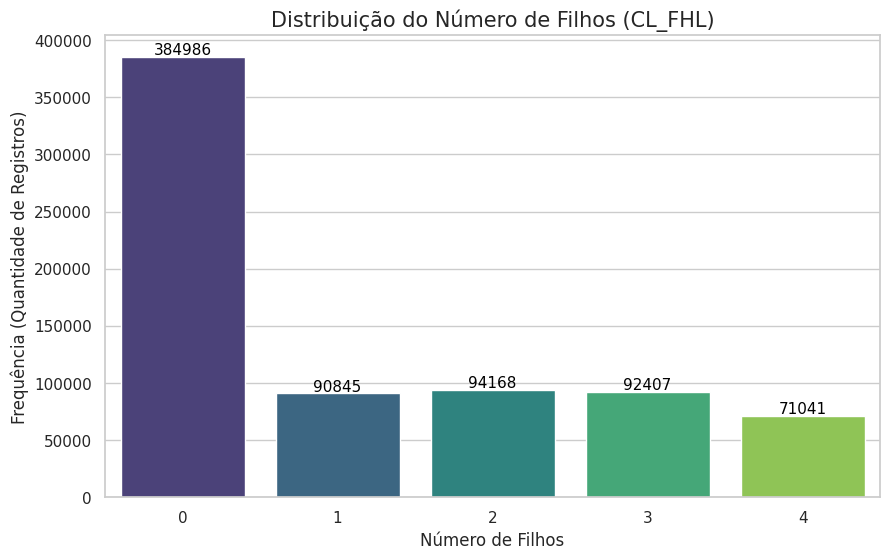

In [13]:

## Visualização da Distribuição de Filhos


# Set the aesthetic style of the plots
sns.set_theme(style='whitegrid')

# Create the visualization
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='CL_FHL', data=df, palette='viridis')

# Add titles and labels
plt.title('Distribuição do Número de Filhos (CL_FHL)', fontsize=15)
plt.xlabel('Número de Filhos', fontsize=12)
plt.ylabel('Frequência (Quantidade de Registros)', fontsize=12)

# Annotate bars with counts
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

## Sprint 5: Relatório Final e Encerramento

Nesta etapa, consolidamos as métricas principais do dataset após todo o processo de limpeza e análise descritiva.

In [14]:
# Cálculo dos indicadores para o relatório final
total_registros = len(df)
total_clientes = df['CL_ID'].nunique()
total_categorias = df['PR_CAT'].nunique()
periodo_inicio = df['DATA'].min().strftime('%d/%m/%Y')
periodo_fim = df['DATA'].max().strftime('%d/%m/%Y')

print("="*40)
print("      RELATÓRIO DE DADOS VAREJO      ")
print("="*40)
print(f"Total de Vendas Processadas: {total_registros:,}")
print(f"Total de Clientes Únicos:    {total_clientes:,}")
print(f"Categorias de Produtos:      {total_categorias}")
print(f"Período Analisado:           {periodo_inicio} a {periodo_fim}")
print(f"Média de Filhos/Cliente:     {df['CL_FHL'].mean():.2f}")
print("="*40)

      RELATÓRIO DE DADOS VAREJO      
Total de Vendas Processadas: 733,447
Total de Clientes Únicos:    1,000
Categorias de Produtos:      7
Período Analisado:           04/01/2019 a 08/12/2022
Média de Filhos/Cliente:     1.15
